# CS 4412 M3 Complete Implementation

## 1. Introduction

This project analyzes the Online Retail dataset to discover purchasing patterns using data mining techniques. The main goal is to identify products that are frequently purchased together and to better understand retail transaction behavior in the United Kingdom.

The analysis focuses on UK transactions after cleaning the dataset by removing missing customer IDs, cancelled invoices, non-positive quantities, and non-positive prices. This scope was chosen to reduce noise and make the analysis more consistent, although it may limit how well the findings generalize to customers in other countries.

For M3, the analysis includes exploratory data analysis (EDA), Apriori association rule mining, and FP-Growth as an expansion beyond M2. The purpose is not only to generate patterns, but also to interpret what those patterns mean in the context of customer purchasing behavior.

## 2. Data Loading

In this section, the Online Retail dataset is loaded into the notebook. The dataset contains transaction-level retail data including invoice numbers, product descriptions, quantities, prices, customer IDs, and country information. This data will be used to analyze purchasing behavior and discover association patterns.

In [4]:
import os
os.listdir('/content')

['.config',
 'online_retail_II.csv',
 '.ipynb_checkpoints',
 'CS4412_M3_Complete_Implementation_Notebook (1).ipynb',
 'sample_data']

In [5]:
import pandas as pd

file_path = '/content/online_retail_II.csv'

df = pd.read_csv(file_path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print(df.shape)
print(df.columns)
df.info()

(1067371, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
# Remove missing values
df = df.dropna(subset=['Customer ID'])

# Remove cancelled invoices (Invoices starting with C)
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Remove negative or zero price
df = df[df['Price'] > 0]

print("Cleaned Shape:", df.shape)

Cleaned Shape: (805549, 8)


In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning and Preprocessing

In this section, the dataset is cleaned to remove incomplete or invalid transactions. Missing customer IDs are removed to ensure transactions can be properly grouped. Cancelled invoices are filtered out to avoid including returned items in the analysis. Transactions with non-positive quantities or prices are also removed to eliminate data entry errors or non-standard records.

The dataset is further filtered to include only United Kingdom transactions. This choice reduces variability and focuses the analysis on a single market, although it may limit generalization to other countries.

In [9]:
df_uk = df[df['Country'] == 'United Kingdom']

print("UK Shape:", df_uk.shape)

UK Shape: (725250, 8)


In [10]:
top_items = (
    df_uk.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_items

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,100720
WHITE HANGING HEART T-LIGHT HOLDER,86327
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,76919
ASSORTED COLOUR BIRD ORNAMENT,74256
BROCADE RING PURSE,70725
JUMBO BAG RED RETROSPOT,69011
PACK OF 60 PINK PAISLEY CAKE CASES,45454
60 TEATIME FAIRY CAKE CASES,40715


## 4. Exploratory Data Analysis

This section explores the cleaned dataset to better understand transaction patterns. The analysis examines the most frequently purchased items, transaction distributions, and product popularity. These insights help identify trends in customer purchasing behavior and guide the association rule mining process.

Exploratory analysis is important because it provides context for interpreting the association rules and helps confirm that the dataset is suitable for pattern discovery.


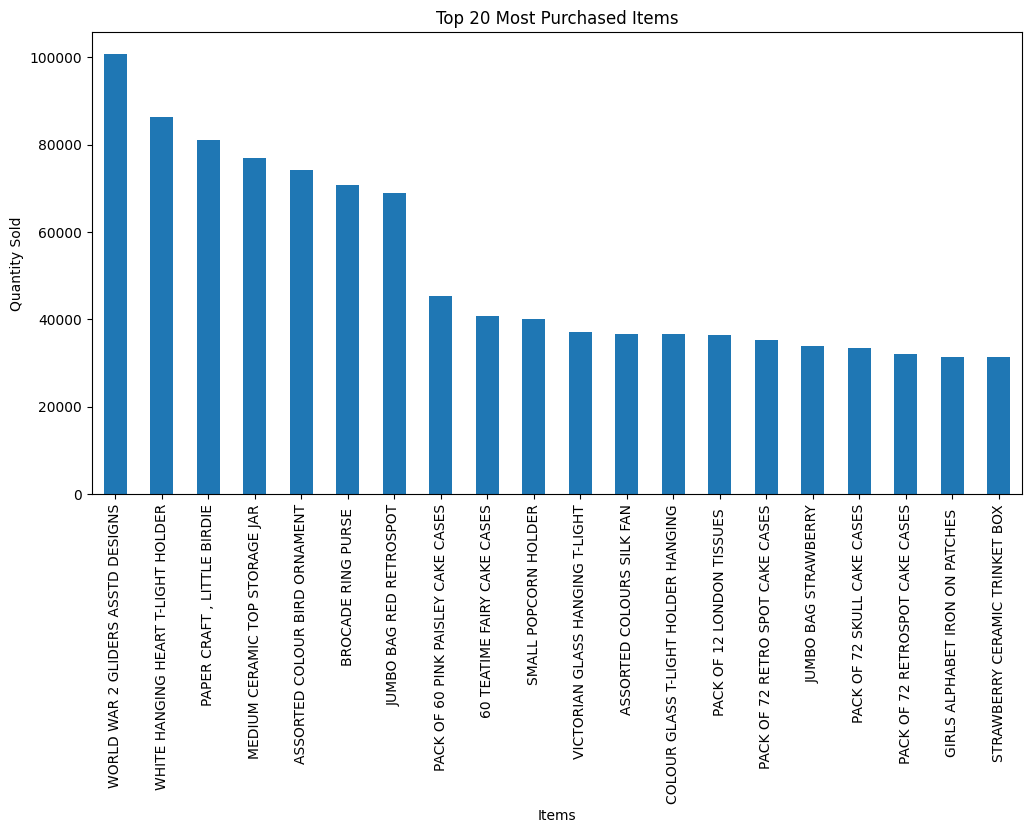

In [11]:
import matplotlib.pyplot as plt

top_items.plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Most Purchased Items')
plt.xlabel('Items')
plt.ylabel('Quantity Sold')
plt.show()

In [12]:
basket_size = df_uk.groupby('Invoice')['Quantity'].sum()

basket_size.describe()

,Quantity
count,33541.000000
mean,259.542441
std,927.335017
min,1.000000
25%,72.000000
50%,150.000000
75%,280.000000
max,87167.000000


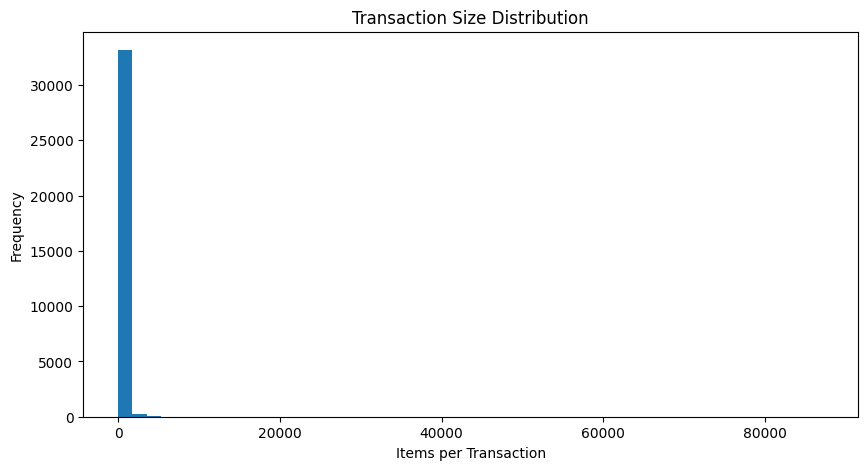

In [13]:
basket_size.plot(kind='hist', bins=50, figsize=(10,5))
plt.title('Transaction Size Distribution')
plt.xlabel('Items per Transaction')
plt.show()

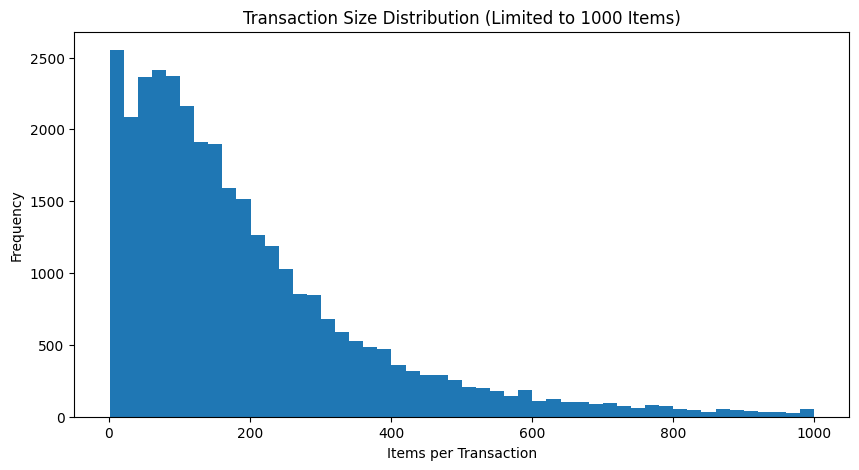

In [14]:
basket_size_limited = basket_size[basket_size <= 1000]

basket_size_limited.plot(kind='hist', bins=50, figsize=(10,5))
plt.title('Transaction Size Distribution (Limited to 1000 Items)')
plt.xlabel('Items per Transaction')
plt.show()

In [15]:
top_countries = df['Country'].value_counts().head(10)
top_countries

,count
Country,
United Kingdom,725250
Germany,16694
EIRE,15743
France,13812
Netherlands,5088
Spain,3719
Belgium,3068
Switzerland,3011
Portugal,2446


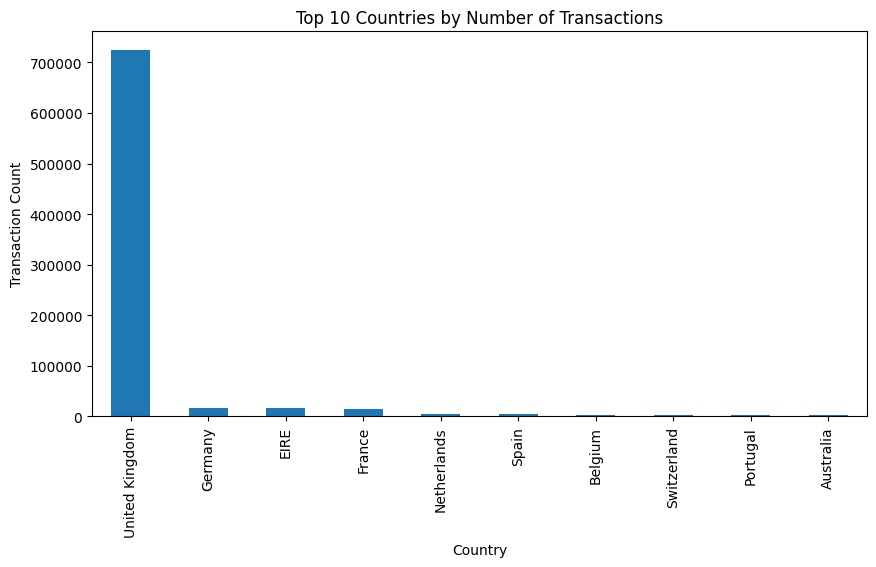

In [16]:
top_countries.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Transaction Count')
plt.show()

In [17]:
basket = (
    df_uk.groupby(['Invoice', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

basket.head()

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
top_200_items = df_uk['Description'].value_counts().head(200).index

basket = basket[top_200_items]

print(basket.shape)

(33541, 200)


In [19]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

/tmp/ipykernel_5589/2737237846.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Description,WHITE HANGING HEART T-LIGHT HOLDER,REGENCY CAKESTAND 3 TIER,ASSORTED COLOUR BIRD ORNAMENT,JUMBO BAG RED RETROSPOT,REX CASH+CARRY JUMBO SHOPPER,LUNCH BAG BLACK SKULL.,PARTY BUNTING,HOME BUILDING BLOCK WORD,HEART OF WICKER SMALL,HEART OF WICKER LARGE,...,ROUND SNACK BOXES SET OF4 WOODLAND,HEART IVORY TRELLIS SMALL,CERAMIC STRAWBERRY CAKE MONEY BANK,JUMBO BAG PINK WITH WHITE SPOTS,RED KITCHEN SCALES,ALARM CLOCK BAKELIKE PINK,MEMO BOARD RETROSPOT DESIGN,CHICK GREY HOT WATER BOTTLE,TRAVEL SEWING KIT,WASHROOM METAL SIGN
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489436,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
489437,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
!pip install mlxtend

## 5. Apriori Implementation

In this section, the Apriori algorithm is applied to discover frequent itemsets and association rules. The dataset is transformed into a basket format where each transaction is represented as a set of purchased items. The Apriori algorithm identifies frequently co-occurring items based on minimum support thresholds.

Association rules are then generated using confidence and lift metrics. These rules help identify meaningful relationships between products that are commonly purchased together.

In [21]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

frequent_itemsets.sort_values(by='support', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

,support,itemsets
0,0.140157,(WHITE HANGING HEART T-LIGHT HOLDER)
1,0.085150,(REGENCY CAKESTAND 3 TIER)
2,0.074655,(ASSORTED COLOUR BIRD ORNAMENT)
3,0.071286,(JUMBO BAG RED RETROSPOT)
6,0.057869,(PARTY BUNTING)
5,0.056707,(LUNCH BAG BLACK SKULL.)
4,0.054948,(REX CASH+CARRY JUMBO SHOPPER)
7,0.052712,(HOME BUILDING BLOCK WORD)
8,0.051579,(HEART OF WICKER SMALL)
9,0.051310,(HEART OF WICKER LARGE)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

rules = rules.sort_values(by='lift', ascending=False)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
16,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.022540,0.456246,13.949822
17,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.022540,0.689152,13.949822
15,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.028979,0.565445,11.772558
14,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.028979,0.603352,11.772558
11,(LOVE BUILDING BLOCK WORD),(HOME BUILDING BLOCK WORD),0.022778,0.528354,10.023487
10,(HOME BUILDING BLOCK WORD),(LOVE BUILDING BLOCK WORD),0.022778,0.432127,10.023487
12,(HEART OF WICKER SMALL),(HEART OF WICKER LARGE),0.025491,0.494220,9.631971
13,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.025491,0.496804,9.631971
6,(LUNCH BAG BLACK SKULL.),(LUNCH BAG SPACEBOY DESIGN ),0.021794,0.384332,7.677718
7,(LUNCH BAG SPACEBOY DESIGN ),(LUNCH BAG BLACK SKULL.),0.021794,0.435378,7.677718


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 6. Apriori Results

The Apriori algorithm generated several strong association rules based on frequent itemsets. These rules identify products that are commonly purchased together. The results are evaluated using support, confidence, and lift metrics.

High lift values indicate strong relationships between products. These patterns provide insight into customer purchasing behavior and potential opportunities for product bundling or recommendation systems.

In [23]:
rules.to_csv('association_rules.csv', index=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

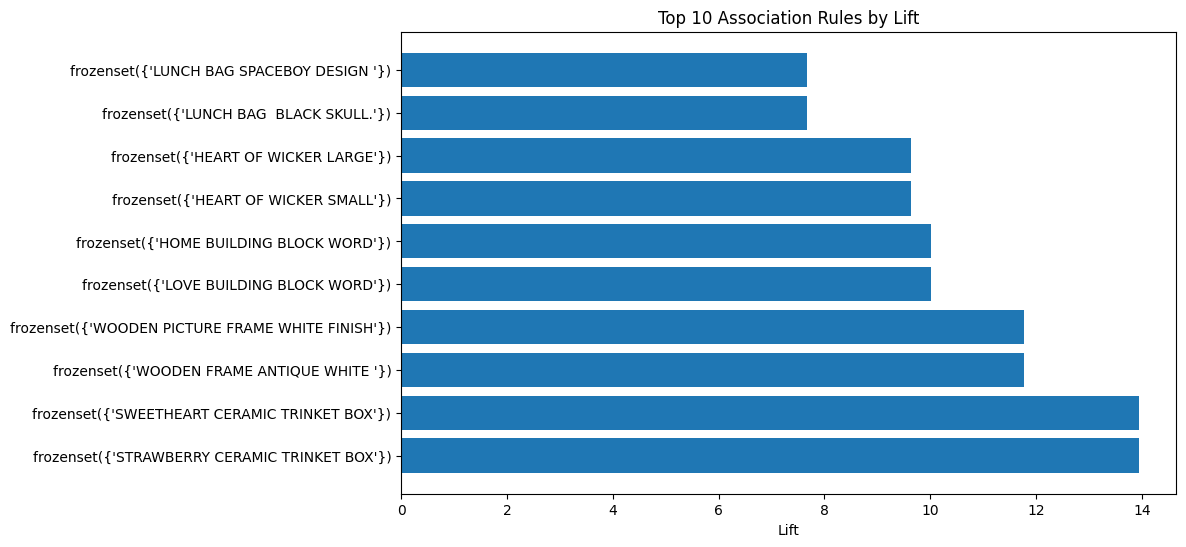

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
top_rules = rules.sort_values('lift', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(range(len(top_rules)), top_rules['lift'])
plt.yticks(range(len(top_rules)), top_rules['antecedents'].astype(str))
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.show()

## 7. FP-Growth Implementation

To expand beyond Apriori, the FP-Growth algorithm is applied as an alternative method for discovering frequent itemsets. FP-Growth is generally more efficient than Apriori because it avoids generating candidate itemsets and instead builds a compact tree structure to identify frequent patterns.

This implementation allows comparison between Apriori and FP-Growth results to evaluate the consistency and reliability of discovered purchasing patterns.

In [25]:
from mlxtend.frequent_patterns import fpgrowth

frequent_fp = fpgrowth(basket, min_support=0.02, use_colnames=True)

frequent_fp.sort_values(by='support', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
12,0.140157,(WHITE HANGING HEART T-LIGHT HOLDER)
116,0.085150,(REGENCY CAKESTAND 3 TIER)
1,0.074655,(ASSORTED COLOUR BIRD ORNAMENT)
129,0.071286,(JUMBO BAG RED RETROSPOT)
71,0.057869,(PARTY BUNTING)
59,0.056707,(LUNCH BAG BLACK SKULL.)
56,0.054948,(REX CASH+CARRY JUMBO SHOPPER)
2,0.052712,(HOME BUILDING BLOCK WORD)
126,0.051579,(HEART OF WICKER SMALL)
127,0.051310,(HEART OF WICKER LARGE)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. FP-Growth Results

The FP-Growth algorithm produced frequent itemsets and association rules similar to those generated by Apriori. The resulting rules were evaluated using support, confidence, and lift metrics to determine the strength of product relationships.

Several high-lift rules were identified, indicating strong co-purchasing behavior between certain products. The similarity between FP-Growth and Apriori results strengthens confidence in the discovered patterns and suggests that the relationships are stable across different mining techniques.

In [26]:
rules_fp = association_rules(frequent_fp, metric="lift", min_threshold=1)

rules_fp = rules_fp.sort_values(by='lift', ascending=False)

rules_fp[['antecedents','consequents','support','confidence','lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
6,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.022540,0.456246,13.949822
7,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.022540,0.689152,13.949822
11,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.028979,0.565445,11.772558
10,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.028979,0.603352,11.772558
1,(LOVE BUILDING BLOCK WORD),(HOME BUILDING BLOCK WORD),0.022778,0.528354,10.023487
0,(HOME BUILDING BLOCK WORD),(LOVE BUILDING BLOCK WORD),0.022778,0.432127,10.023487
17,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.025491,0.496804,9.631971
16,(HEART OF WICKER SMALL),(HEART OF WICKER LARGE),0.025491,0.494220,9.631971
14,(LUNCH BAG BLACK SKULL.),(LUNCH BAG SPACEBOY DESIGN ),0.021794,0.384332,7.677718
15,(LUNCH BAG SPACEBOY DESIGN ),(LUNCH BAG BLACK SKULL.),0.021794,0.435378,7.677718


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 9. Association Rule Interpretation

The association rule mining results reveal several strong purchasing patterns in the UK retail dataset.

One of the strongest rules shows that customers who purchase "Strawberry Ceramic Trinket Box" are highly likely to also purchase "Sweetheart Ceramic Trinket Box". This rule has a very high lift value, indicating that the items are strongly related and frequently purchased together. This suggests that these products may be complementary items and could benefit from bundling or joint promotions.

Another strong pattern appears between "Wooden Frame Antique White" and "Wooden Picture Frame White Finish". This relationship suggests customers frequently purchase coordinated decorative items, indicating a preference for matching home décor products.

Additionally, the rule connecting "Heart of Wicker Small" and "Heart of Wicker Large" suggests customers often purchase multiple sizes of the same product. This behavior indicates potential opportunities for size-based bundles or multi-item discounts.

The FP-Growth algorithm produced similar high-lift rules to Apriori, confirming the consistency of discovered patterns and strengthening confidence in the results.